In [1]:
import numpy as np
import mo_gymnasium as mo_gym
from scipy.optimize import minimize, LinearConstraint, Bounds
from numpy.linalg import matrix_rank, pinv
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from IPython import display
from itertools import product

import torch
import torch.nn.functional as F

from scipy.interpolate import PchipInterpolator

import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors

import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

/Users/liuyuan/venvs/morl/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [65]:
DEVICE = "cpu" # torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(DEVICE)

FIG_PATH = "figure/"
plt.rcParams.update({

    # Figure
    "figure.figsize": (7, 5),
    "figure.dpi": 120,

    # Font
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "legend.fontsize": 16,

    # Lines
    "lines.linewidth": 2.0,
    "lines.markersize": 8,

    # Axes
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.5,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Legend
    "legend.frameon": False,

    # Layout
    "figure.autolayout": True
})

# DST

In [66]:
#  A. Build a tabular DST model from MO-Gymnasium
def get_dst_grid(env):
    uenv = env.unwrapped
    candidate_names = ["sea_map", "dst_map", "map", "_map", "grid", "treasure_map"]
    for name in candidate_names:
        if hasattr(uenv, name):
            arr = np.array(getattr(uenv, name))
            if arr.ndim == 2:
                return arr, name
    raise AttributeError("Could not find a 2D map attribute in env.unwrapped.")


def build_dst_tabular_model(env):
    """
    Build a deterministic tabular model for Deep-Sea-Treasure.

    Returns
    -------
    model : dict
        {
            "states": list of (r, c) + [("terminal",)],
            "state_to_idx": dict,
            "idx_to_state": dict,
            "S": int,
            "A": int,
            "P": np.ndarray of shape (S, A, S),
            "R": np.ndarray of shape (S, A, 2),
            "rho0": np.ndarray of shape (S,),
            "terminal_idx": int,
            "treasure_mask": np.ndarray of shape (S,),
            "valid_mask": np.ndarray of shape (S, A),
        }
    """
    grid, grid_name = get_dst_grid(env)
    nrow, ncol = grid.shape

    # Convention:
    # - sea cells: 0
    # - treasure cells: positive
    # - blocked cells: usually -10 or similar in some implementations
    # We treat positive cells as treasure/terminal-on-entry.
    # Everything else except hard-blocked cells is traversable.
    def is_blocked(v):
        # adjust if needed after inspecting Our exact map
        return v == -10

    def is_treasure(v):
        return v > 0

    states = []
    for r in range(nrow):
        for c in range(ncol):
            if not is_blocked(grid[r, c]):
                states.append((r, c))

    terminal_state = ("terminal",)
    states.append(terminal_state)

    state_to_idx = {s: i for i, s in enumerate(states)}
    idx_to_state = {i: s for s, i in state_to_idx.items()}

    S = len(states)
    A = 4  # up, right, down, left
    terminal_idx = state_to_idx[terminal_state]

    # actions: up, right, down, left
    deltas = [(-1, 0), (0, 1), (1, 0), (0, -1)]

    P = np.zeros((S, A, S), dtype=np.float32)
    R = np.zeros((S, A, 2), dtype=np.float32)
    valid_mask = np.ones((S, A), dtype=bool)
    treasure_mask = np.zeros(S, dtype=bool)

    for s_idx, s in enumerate(states):
        if s == terminal_state:
            for a in range(A):
                P[s_idx, a, terminal_idx] = 1.0
                R[s_idx, a, :] = 0.0
            continue

        r, c = s
        cell_val = grid[r, c]
        if is_treasure(cell_val):
            treasure_mask[s_idx] = True
            # once in treasure state, force transition to terminal
            for a in range(A):
                P[s_idx, a, terminal_idx] = 1.0
                R[s_idx, a, :] = 0.0
            continue

        for a, (dr, dc) in enumerate(deltas):
            nr, nc = r + dr, c + dc

            # bounce against wall / blocked
            if nr < 0 or nr >= nrow or nc < 0 or nc >= ncol or is_blocked(grid[nr, nc]):
                nr, nc = r, c

            next_cell = grid[nr, nc]

            # objective 1: treasure reward
            # objective 2: time penalty
            if is_treasure(next_cell):
                next_idx = state_to_idx[(nr, nc)]
                P[s_idx, a, next_idx] = 1.0
                R[s_idx, a, 0] = float(next_cell)
                R[s_idx, a, 1] = -1.0
            else:
                next_idx = state_to_idx[(nr, nc)]
                P[s_idx, a, next_idx] = 1.0
                R[s_idx, a, 0] = 0.0
                R[s_idx, a, 1] = -1.0

    # initial state from env.reset()
    obs, _ = env.reset()
    init_state = tuple(obs.tolist()) if hasattr(obs, "tolist") else tuple(obs)
    rho0 = np.zeros(S, dtype=np.float32)
    rho0[state_to_idx[init_state]] = 1.0

    model = {
        "grid_name": grid_name,
        "grid": grid,
        "states": states,
        "state_to_idx": state_to_idx,
        "idx_to_state": idx_to_state,
        "S": S,
        "A": A,
        "P": P,
        "R": R,
        "rho0": rho0,
        "terminal_idx": terminal_idx,
        "treasure_mask": treasure_mask,
        "valid_mask": valid_mask,
    }
    return model



#  B. Policy-space exact evaluation
def make_uniform_pi_ref(S, A):
    return np.full((S, A), 1.0 / A, dtype=np.float32)


def discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma):
    """
    pi:    (S, A)
    P_t:   (S, A, S)
    rho0_t:(S,)
    returns d_pi: (S,)
        normalized discounted state occupancy:
        d^T = (1-gamma) rho0^T (I - gamma P_pi)^(-1)
    """
    P_pi = torch.einsum("sa,san->sn", pi, P_t)   # (S, S)
    I = torch.eye(P_pi.shape[0], dtype=P_pi.dtype, device=P_pi.device)
    M = I - gamma * P_pi
    rhs = (1.0 - gamma) * rho0_t
    # Solve M^T x = rhs for row-vector form equivalently
    d = torch.linalg.solve(M.T, rhs)
    return d


def evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t):
    """
    logits: (S, A)

    Returns
    -------
    out : dict with keys
        pi, d, mu, R1, R2, reg, obj_vec
    """
    pi = F.softmax(logits, dim=-1)  # (S, A)
    d = discounted_state_dist_from_policy_torch(pi, P_t, rho0_t, gamma)  # (S,)
    mu = d.unsqueeze(-1) * pi  # (S, A)

    # Expected vector returns under normalized discounted occupancy
    R1 = torch.sum(mu * R_t[..., 0])
    R2 = torch.sum(mu * R_t[..., 1])

    # KL(pi || pi_ref) weighted by d_pi(s)
    log_pi = torch.log(pi + 1e-12)
    log_pi_ref = torch.log(pi_ref_t + 1e-12)
    kl_state = torch.sum(pi * (log_pi - log_pi_ref), dim=-1)  # (S,)
    reg = tau * torch.sum(d * kl_state)

    return {
        "pi": pi,
        "d": d,
        "mu": mu,
        "R1": R1,
        "R2": R2,
        "reg": reg,
        "obj_vec": torch.stack([R1, R2]),
    }


def scalarized_objective_torch(logits, w, P_t, R_t, rho0_t, gamma, tau, pi_ref_t):
    """
    Maximize:
        (1-w) R1 + w R2 - reg
    """
    out = evaluate_policy_torch(logits, P_t, R_t, rho0_t, gamma, tau, pi_ref_t)
    scalar = (1.0 - w) * out["R1"] + w * out["R2"] - out["reg"]
    return scalar, out


#  C. Inner solver in policy space
def solve_policy_scalarization(
    w,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    logits_init=None,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=DEVICE,
    verbose=False,
):
    """
    Solves max_pi (1-w)R1 + wR2 - tau * E_d[ KL(pi || pi_ref) ]
    using gradient ascent on tabular logits.
    """
    P_t = torch.tensor(P, dtype=torch.float32, device=device)
    R_t = torch.tensor(R, dtype=torch.float32, device=device)
    rho0_t = torch.tensor(rho0, dtype=torch.float32, device=device)
    pi_ref_t = torch.tensor(pi_ref, dtype=torch.float32, device=device)

    S, A = pi_ref.shape

    if logits_init is None:
        logits = torch.zeros((S, A), dtype=torch.float32, device=device, requires_grad=True)
    else:
        logits = torch.tensor(logits_init, dtype=torch.float32, device=device, requires_grad=True)

    opt = torch.optim.Adam([logits], lr=lr)

    prev_val = None
    history = []

    for it in range(maxiter):
        opt.zero_grad()
        scalar, out = scalarized_objective_torch(
            logits, w=w, P_t=P_t, R_t=R_t, rho0_t=rho0_t,
            gamma=gamma, tau=tau, pi_ref_t=pi_ref_t
        )
        loss = -scalar
        loss.backward()
        opt.step()

        val = scalar.item()
        history.append(val)

        if verbose and (it % 50 == 0 or it == maxiter - 1):
            print(
                f"[w={w:.3f}] iter={it:4d} "
                f"scalar={val:.8f} R1={out['R1'].item():.6f} "
                f"R2={out['R2'].item():.6f} reg={out['reg'].item():.6f}"
            )

        if prev_val is not None and abs(val - prev_val) < tol:
            break
        prev_val = val

    with torch.no_grad():
        scalar, out = scalarized_objective_torch(
            logits, w=w, P_t=P_t, R_t=R_t, rho0_t=rho0_t,
            gamma=gamma, tau=tau, pi_ref_t=pi_ref_t
        )

    return {
        "w": w,
        "logits": logits.detach().cpu().numpy(),
        "pi": out["pi"].detach().cpu().numpy(),
        "d": out["d"].detach().cpu().numpy(),
        "mu": out["mu"].detach().cpu().numpy(),
        "R1": out["R1"].item(),
        "R2": out["R2"].item(),
        "reg": out["reg"].item(),
        "scalar": scalar.item(),
        "history": history,
    }

In [67]:
#  D. CDF refinement in policy space
def solve_cdf_refinement_policy(
    N_points,
    P,
    R,
    rho0,
    gamma,
    tau,
    pi_ref,
    max_outer_iters=10,
    alpha=0.8,
    inner_maxiter=300,
    inner_lr=0.05,
    inner_tol=1e-8,
    logits0=None,
    logits1=None,
    init_from_prev=True,
    device=DEVICE,
    verbose=False,
):
    """
    Outer iterate is the CDF F_t on a fixed fine grid.
    Inner solver optimizes directly over tabular policy logits.
    """
    quantiles = np.linspace(0.0, 1.0, N_points)
    fine_w = np.linspace(0.0, 1.0, 2001)
    F_vals = fine_w.copy()  # F_0(w) = w

    S, A = pi_ref.shape

    # warm-start storage
    current_logits = [None for _ in range(N_points)]
    if logits0 is not None and logits1 is not None:
        current_logits = [
            (1.0 - q) * logits0 + q * logits1 for q in quantiles
        ]

    pf_history = []
    pf_history_raw = []
    policy_history = []
    weight_history = []

    for t in range(max_outer_iters):
        current_w = np.interp(quantiles, F_vals, fine_w)
        weight_history.append(current_w.copy())

        if verbose:
            print(f"\n--- Outer iteration {t} ---")
            print("weights:", np.round(current_w, 4))

        results_t = []
        f_coords = []

        for n, w in enumerate(current_w):
            if init_from_prev and current_logits[n] is not None:
                logits_init = current_logits[n]
            elif logits0 is not None and logits1 is not None:
                logits_init = (1.0 - w) * logits0 + w * logits1
            else:
                logits_init = np.zeros((S, A), dtype=np.float32)

            sol = solve_policy_scalarization(
                w=w,
                P=P,
                R=R,
                rho0=rho0,
                gamma=gamma,
                tau=tau,
                pi_ref=pi_ref,
                logits_init=logits_init,
                lr=inner_lr,
                maxiter=inner_maxiter,
                tol=inner_tol,
                device=device,
                verbose=False,
            )
            current_logits[n] = sol["logits"]
            results_t.append(sol)
            f_coords.append([sol["R1"], sol["R2"]])
            # f_coords_reg.append([sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]])
        
        f_coords = np.asarray(f_coords, dtype=np.float32)

        pf_history.append(f_coords)
        
        policy_history.append(results_t)

        # empirical arc-length CDF on current points
        diffs = np.diff(f_coords, axis=0)
        seg_lens = np.sqrt(np.sum(diffs ** 2, axis=1))
        s_vals = np.concatenate([[0.0], np.cumsum(seg_lens)])
        total_len = s_vals[-1]

        if total_len <= 1e-14:
            if verbose:
                print("PF length is zero. Stopping.")
            break

        tilde_F_values = s_vals / total_len

        # build \tilde F_t on fine grid
        interp_tilde_F = PchipInterpolator(current_w, tilde_F_values)
        tilde_vals = interp_tilde_F(fine_w)

        # update F_{t+1} = (1-alpha) F_t + alpha \tilde F_t
        F_vals = (1.0 - alpha) * F_vals + alpha * tilde_vals

        # safeguard
        F_vals = np.maximum.accumulate(F_vals)
        F_vals[0] = 0.0
        F_vals[-1] = 1.0

        if verbose:
            print(f"total PF length = {total_len:.6f}")

    final_w = np.interp(quantiles, F_vals, fine_w)

    return {
        "final_w": final_w,
        "final_logits": current_logits,
        "pf_history": pf_history,
        "policy_history": policy_history,
        "weight_history": weight_history,
        "F_grid_w": fine_w,
        "F_grid_vals": F_vals,
    }

### Baselines

In [68]:
# from morl_baselines.multi_policy.envelope.envelope import Envelope
# from morl_baselines.multi_policy.pareto_q_learning.pql import PQL
# from morl_baselines.multi_policy.pcn.pcn import PCN

from morl_baselines.multi_policy.linear_support.linear_support import LinearSupport
# import numpy as np

In [69]:
def run_ols_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=300,
    inner_lr=0.05,
    inner_tol=1e-8,
    epsilon_ols=1e-6,
    logits0=None,
    logits1=None,
    init_mode="interp",   # "interp", "prev", or "zero"
    duplicate_tol=1e-6,
    max_total_queries=None,   # optional cap on total oracle calls
    device=DEVICE,
    verbose=True,
):
    """
    MORL-Baselines OLS outer loop + your exact scalarized policy solver.

    Keeps only distinct solutions in objective space.
    A solution is considered duplicate if [R1, R2, reg] is too close
    to a previously accepted one.

    Returns:
        {
            "weights": (K, 2) accepted OLS weight vectors,
            "scalar_weights": (K,) accepted scalar weights w in [0,1],
            "results": list of accepted solver outputs,
            "pf_reward": (K,2) array of [R1, R2],
            "pf_reg_reward": (K,2) array of [R1-reg, R2-reg],
            "pf_cost": (K,2) array of [-R1+reg, -R2+reg],
            "num_queries": total number of oracle solves,
            "ols": LinearSupport object
        }
    """
    ols = LinearSupport(num_objectives=2, epsilon=epsilon_ols, verbose=verbose)

    accepted_results = []
    accepted_weight_vecs = []
    prev_logits = None
    num_queries = 0

    if max_total_queries is None:
        max_total_queries = max(10 * N_points, 50)

    def is_duplicate_solution(sol, accepted, tol=duplicate_tol):
        p = np.array([sol["R1"], sol["R2"], sol["reg"]], dtype=np.float64)
        for old in accepted:
            q = np.array([old["R1"], old["R2"], old["reg"]], dtype=np.float64)
            if np.linalg.norm(p - q, ord=2) < tol:
                return True
        return False

    while len(accepted_results) < N_points and num_queries < max_total_queries:
        w_vec = ols.next_weight(algo="ols")
        if w_vec is None:
            if verbose:
                print("[OLS] next_weight returned None; stopping.")
            break

        w_vec = np.asarray(w_vec, dtype=np.float64)
        assert w_vec.shape == (2,), f"Expected 2D weight vector, got {w_vec.shape}"
        assert w_vec.sum() > 0, "OLS returned a nonpositive weight vector sum"
        w_vec = w_vec / w_vec.sum()
        w = float(w_vec[1])

        if init_mode == "interp" and logits0 is not None and logits1 is not None:
            logits_init = (1.0 - w) * logits0 + w * logits1
        elif init_mode == "prev" and prev_logits is not None:
            logits_init = prev_logits
        else:
            logits_init = None

        sol = solve_policy_scalarization(
            w=w,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
            verbose=False,
        )
        num_queries += 1

        # Value vector for OLS: this exactly matches
        # (1-w) R1 + w R2 - reg
        value = np.array(
            [sol["R1"] - sol["reg"], sol["R2"] - sol["reg"]],
            dtype=np.float64
        )

        # Always feed the solution back to OLS so its outer logic can proceed
        ols.add_solution(value=value, w=w_vec)

        dup = is_duplicate_solution(sol, accepted_results, tol=duplicate_tol)

        if verbose:
            msg = (
                f"[OLS] query #{num_queries:02d}  "
                f"w={w:.6f}  "
                f"value=[{value[0]:.8f}, {value[1]:.8f}]  "
                f"raw=[{sol['R1']:.8f}, {sol['R2']:.8f}]  "
                f"reg={sol['reg']:.8f}"
            )
            if dup:
                msg += "  --> duplicate, skipped"
            print(msg)

        if not dup:
            accepted_results.append(sol)
            accepted_weight_vecs.append(w_vec)
            if hasattr(sol["logits"], "detach"):
                prev_logits = sol["logits"].detach().clone()
            else:
                prev_logits = sol["logits"]

        if ols.ended():
            if verbose:
                print("[OLS] ended() is True; stopping.")
            break

    if len(accepted_results) == 0:
        return {
            "weights": np.zeros((0, 2)),
            "scalar_weights": np.zeros((0,)),
            "results": [],
            "pf_reward": np.zeros((0, 2)),
            "pf_reg_reward": np.zeros((0, 2)),
            "pf_cost": np.zeros((0, 2)),
            "num_queries": num_queries,
            "ols": ols,
        }

    scalar_ws = np.array([wv[1] for wv in accepted_weight_vecs], dtype=np.float64)
    order = np.argsort(scalar_ws)

    accepted_results = [accepted_results[i] for i in order]
    accepted_weight_vecs = np.array(accepted_weight_vecs, dtype=np.float64)[order]
    scalar_ws = scalar_ws[order]

    pf_reward = np.array(
        [[r["R1"], r["R2"]] for r in accepted_results],
        dtype=np.float64
    )

    pf_reg_reward = np.array(
        [[r["R1"] - r["reg"], r["R2"] - r["reg"]] for r in accepted_results],
        dtype=np.float64
    )

    pf_cost = np.array(
        [[-r["R1"] + r["reg"], -r["R2"] + r["reg"]] for r in accepted_results],
        dtype=np.float64
    )

    return {
        "weights": accepted_weight_vecs,
        "scalar_weights": scalar_ws,
        "results": accepted_results,
        "pf": pf_reg_reward,           # use regularized reward as the default PF
        "pf_reward": pf_reward,
        "pf_reg_reward": pf_reg_reward,
        "pf_cost": pf_cost,
        "num_queries": num_queries,
        "ols": ols,
    }

In [7]:
#  E. Baselines with the same inner policy optimizer
def run_uniform_weights_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    inner_maxiter=300,
    inner_lr=0.05,
    inner_tol=1e-8,
    logits0=None,
    logits1=None,
    device=DEVICE,
):
    weights = np.linspace(0.0, 1.0, N_points)
    results = []
    prev_logits = None

    for w in weights:
        logits_init = prev_logits
        if logits_init is None:
            if logits0 is not None and logits1 is not None:
                logits_init = (1.0 - w) * logits0 + w * logits1

        sol = solve_policy_scalarization(
            w=w,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
        )
        results.append(sol)
        prev_logits = sol["logits"]

    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)
    return {"weights": weights, "results": results, "pf": pf}


def run_random_weights_policy_baseline(
    N_points,
    P, R, rho0, gamma, tau, pi_ref,
    seed=0,
    inner_maxiter=300,
    inner_lr=0.05,
    inner_tol=1e-8,
    device=DEVICE,
):
    rng = np.random.default_rng(seed)
    weights = np.sort(rng.uniform(0.0, 1.0, size=N_points))
    weights[0] = 0.0
    weights[-1] = 1.0

    results = []
    prev_logits = None

    for w in weights:
        sol = solve_policy_scalarization(
            w=w,
            P=P,
            R=R,
            rho0=rho0,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=prev_logits,
            lr=inner_lr,
            maxiter=inner_maxiter,
            tol=inner_tol,
            device=device,
        )
        results.append(sol)
        prev_logits = sol["logits"]

    pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)
    return {"weights": weights, "results": results, "pf": pf}


# def run_greedy_gap_refinement_baseline(
#     N_points,
#     P, R, rho0, gamma, tau, pi_ref,
#     inner_maxiter=300,
#     inner_lr=0.05,
#     inner_tol=1e-8,
#     device=DEVICE,
# ):
#     """
#     Start with w={0,1}; repeatedly insert midpoint into the largest PF gap.
#     This is a useful adaptive baseline against Our CDF refinement.
#     """
#     cache = {}

#     def solve_at_w(w, logits_init=None):
#         key = round(float(w), 12)
#         if key not in cache:
#             cache[key] = solve_policy_scalarization(
#                 w=w,
#                 P=P,
#                 R=R,
#                 rho0=rho0,
#                 gamma=gamma,
#                 tau=tau,
#                 pi_ref=pi_ref,
#                 logits_init=logits_init,
#                 lr=inner_lr,
#                 maxiter=inner_maxiter,
#                 tol=inner_tol,
#                 device=device,
#             )
#         return cache[key]

#     solve_at_w(0.0)
#     solve_at_w(1.0)

#     while len(cache) < N_points:
#         ws = np.array(sorted(cache.keys()))
#         pf = np.array([[cache[w]["R1"], cache[w]["R2"]] for w in ws])

#         segs = np.sqrt(np.sum(np.diff(pf, axis=0) ** 2, axis=1))
#         k = int(np.argmax(segs))
#         w_new = 0.5 * (ws[k] + ws[k + 1])

#         logits_init = 0.5 * (cache[ws[k]]["logits"] + cache[ws[k + 1]]["logits"])
#         solve_at_w(w_new, logits_init=logits_init)

#     ws = np.array(sorted(cache.keys()))
#     results = [cache[w] for w in ws]
#     pf = np.array([[r["R1"], r["R2"]] for r in results], dtype=np.float32)
#     return {"weights": ws, "results": results, "pf": pf}

In [8]:
#  F. Coverage metrics
def front_segment_lengths(pf):
    if len(pf) < 2:
        return np.array([])
    return np.sqrt(np.sum(np.diff(pf, axis=0) ** 2, axis=1))

def arc_length_cv(pf):
    segs = front_segment_lengths(pf)
    if len(segs) == 0 or np.mean(segs) <= 1e-15:
        return np.nan
    return np.std(segs) / np.mean(segs)

def max_min_gap_ratio(pf):
    segs = front_segment_lengths(pf)
    if len(segs) == 0 or np.min(segs) <= 1e-15:
        return np.nan
    return np.max(segs) / np.min(segs)

def empirical_arc_cdf_error(pf):
    """
    L_infty error of empirical normalized cumulative arc-length
    against uniform quantiles at sample indices.
    """
    segs = front_segment_lengths(pf)
    if len(segs) == 0:
        return np.nan
    s = np.concatenate([[0.0], np.cumsum(segs)])
    s = s / s[-1]
    q = np.linspace(0.0, 1.0, len(pf))
    return np.max(np.abs(s - q))

def calculate_relative_rms_err(pf):
    """
    Implements Err_arc as defined in the provided equation:
    RMS of ( (segment_length / (Total_L / N)) - 1 )
    """
    if len(pf) < 2:
        return np.nan
    
    # Calculate s_w(w_{n+1}) - s_w(w_n)
    diffs = np.diff(pf, axis=0)
    seg_lens = np.sqrt(np.sum(diffs**2, axis=1))
    
    L = np.sum(seg_lens)
    N_segments = len(seg_lens)
    
    if L < 1e-12:
        return 0.0
    
    ideal_len = L / N_segments
    # The term inside the sum: (delta_s / ideal - 1)
    relative_deviations = (seg_lens / ideal_len) - 1.0
    
    # RMS: sqrt( (1/N) * sum( deviations^2 ) )
    rms_err = np.sqrt(np.mean(relative_deviations**2))
    return rms_err


In [70]:
def plot_dst_grid(model, show_start=True, save_path = FIG_PATH + "DST_map.pdf"):
    """
    Plot the Deep Sea Treasure grid map without trajectories.
    """

    grid = model["grid"]

    map_colors = {
        "wall": "#2B2B2B",
        "water": "#F4FBFD",
        "treasure": "#8C6A0A",
        "text": "#FFD700",
        "gridline": "#D6EAF0",
        "start": "#d62728"
    }

    fig, ax = plt.subplots(figsize=(6,6))

    ax.set_facecolor(map_colors["water"])

    # grid lines
    for x in np.arange(-0.5, grid.shape[1], 1):
        ax.axvline(x, color=map_colors["gridline"], lw=0.8, zorder=0)

    for y in np.arange(-0.5, grid.shape[0], 1):
        ax.axhline(y, color=map_colors["gridline"], lw=0.8, zorder=0)

    # draw map
    for r in range(grid.shape[0]):
        for c in range(grid.shape[1]):

            val = grid[r, c]

            if val == -10:   # wall
                ax.add_patch(
                    plt.Rectangle(
                        (c-0.5, r-0.5),
                        1,1,
                        color=map_colors["wall"],
                        zorder=1
                    )
                )

            elif val > 0:    # treasure
                ax.add_patch(
                    plt.Rectangle(
                        (c-0.5, r-0.5),
                        1,1,
                        color=map_colors["treasure"],
                        alpha=0.9,
                        zorder=1
                    )
                )

                ax.text(
                    c, r,
                    f"{int(val)}",
                    color=map_colors["text"],
                    ha="center",
                    va="center",
                    fontweight="bold",
                    # fontsize=10,
                    zorder=2
                )

    # mark start position
    if show_start:
        start_state = model.get("start_state", (0,0))

        ax.scatter(
            start_state[1],
            start_state[0],
            s=150,
            color=map_colors["start"],
            marker="*",
            edgecolor="black",
            zorder=3,
            label="Start"
        )

        ax.legend(loc="upper right")

    ax.set_title("Deep Sea Treasure Grid Map", fontsize=14, fontweight="bold")

    ax.axis("image")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlim(-0.5, grid.shape[1]-0.5)
    ax.set_ylim(grid.shape[0]-0.5, -0.5)

    plt.savefig(save_path, bbox_inches="tight")

    plt.show()

/Users/liuyuan/venvs/morl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


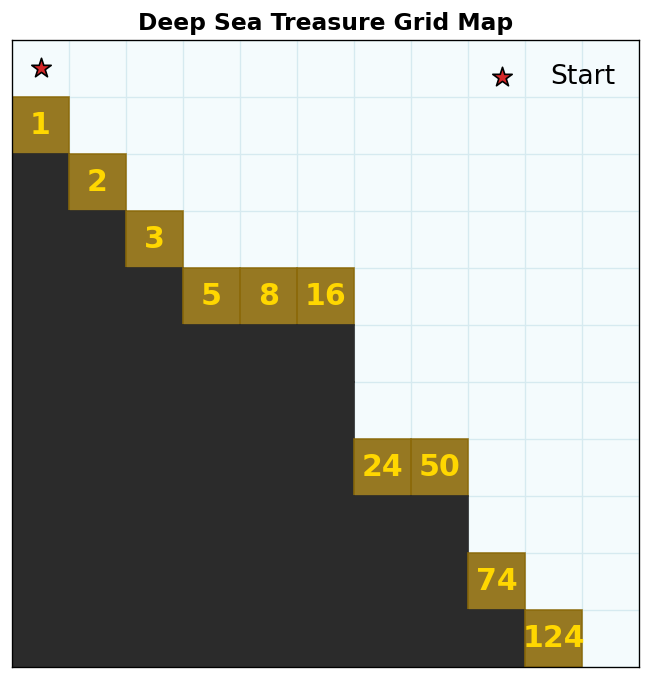

In [71]:
ENV_ID = "deep-sea-treasure-concave-v0"   # or "deep-sea-treasure-v0"
env = mo_gym.make(ENV_ID)
model = build_dst_tabular_model(env)

P = model["P"]
R = model["R"]
rho0 = model["rho0"]
S = model["S"]
A = model["A"]

plot_dst_grid(model)

In [26]:
# IGD
#  G. Example run
gamma = 0.999
tau = 1.5 #3.
pi_ref = make_uniform_pi_ref(S, A)


# endpoint solves for warm starts
sol0 = solve_policy_scalarization(
    w=0.0, P=P, R=R, rho0=rho0, gamma=gamma, tau=tau, pi_ref=pi_ref,
    lr=0.01, maxiter=500, device = DEVICE
)
sol1 = solve_policy_scalarization(
    w=1.0, P=P, R=R, rho0=rho0, gamma=gamma, tau=tau, pi_ref=pi_ref,
    lr=0.01, maxiter=500, device = DEVICE
)


out_cdf_dense = solve_cdf_refinement_policy(
    N_points=51,
    P=P, R=R, rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    max_outer_iters=500,
    alpha=.9,
    inner_maxiter=3,
    inner_lr=0.03,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_from_prev=True,
    verbose=True,
)

def igd(pf, ref_pf = out_cdf_dense["pf_history"][-1]):
    """
    Inverted Generational Distance:
        IGD(P, R) = mean_{r in R} min_{p in P} ||r - p||_2
    Lower is better.
    """
    pf = np.asarray(pf, dtype=float)
    ref_pf = np.asarray(ref_pf, dtype=float)

    if len(pf) == 0 or len(ref_pf) == 0:
        return np.nan

    dists = np.linalg.norm(ref_pf[:, None, :] - pf[None, :, :], axis=2)
    return np.mean(np.min(dists, axis=1))


--- Outer iteration 0 ---
weights: [0.   0.02 0.04 0.06 0.08 0.1  0.12 0.14 0.16 0.18 0.2  0.22 0.24 0.26
 0.28 0.3  0.32 0.34 0.36 0.38 0.4  0.42 0.44 0.46 0.48 0.5  0.52 0.54
 0.56 0.58 0.6  0.62 0.64 0.66 0.68 0.7  0.72 0.74 0.76 0.78 0.8  0.82
 0.84 0.86 0.88 0.9  0.92 0.94 0.96 0.98 1.  ]
total PF length = 0.132650

--- Outer iteration 1 ---
weights: [0.     0.0176 0.0772 0.1379 0.185  0.2229 0.2539 0.2798 0.3018 0.3209
 0.3379 0.3529 0.3666 0.3792 0.3911 0.4022 0.4126 0.4225 0.4318 0.4408
 0.4496 0.458  0.466  0.4735 0.4804 0.4866 0.4925 0.4982 0.5038 0.5093
 0.5148 0.5202 0.5257 0.5311 0.5366 0.5424 0.5483 0.5545 0.5611 0.5682
 0.5758 0.5844 0.594  0.6053 0.6187 0.6364 0.6594 0.6935 0.7517 0.8516
 1.    ]
total PF length = 0.134526

--- Outer iteration 2 ---
weights: [0.     0.0337 0.0592 0.1218 0.2721 0.3311 0.3643 0.3866 0.4029 0.4155
 0.4257 0.4341 0.4416 0.4482 0.4541 0.4593 0.4639 0.4682 0.4721 0.4756
 0.4787 0.4813 0.4834 0.4854 0.4873 0.489  0.4907 0.4923 0.4939 0.4954
 

KeyboardInterrupt: 

### Run the problem

In [227]:
N = 11

# Our method
out_cdf = solve_cdf_refinement_policy(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    max_outer_iters=30,
    alpha=0.3,
    inner_maxiter=50,
    inner_lr=0.02,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_from_prev=True,
    verbose=True,
)

pf_cdf = out_cdf["pf_history"][-1]

# Uniform baseline
out_uni = run_uniform_weights_policy_baseline(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    inner_maxiter=50*30, inner_lr=0.02,
    logits0=sol0["logits"], logits1=sol1["logits"],
)
pf_uni = out_uni["pf"]

# Random baseline
out_rand = run_random_weights_policy_baseline(
    N_points=N,
    P=P, R=R, rho0=rho0,
    gamma=gamma, tau=tau, pi_ref=pi_ref,
    seed=0,
    inner_maxiter=50*30, inner_lr=0.02,
)
pf_rand = out_rand["pf"]

# # Greedy gap baseline
# out_gap = run_greedy_gap_refinement_baseline(
#     N_points=N,
#     P=P, R=R, rho0=rho0,
#     gamma=gamma, tau=tau, pi_ref=pi_ref,
#     inner_maxiter=300*30, inner_lr=0.05,
# )
# pf_gap = out_gap["pf"]

out_ols = run_ols_policy_baseline(
    N_points=N,
    P=P,
    R=R,
    rho0=rho0,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref,
    inner_maxiter=50*30,
    inner_lr=0.02,
    inner_tol=1e-8,
    epsilon_ols=1e-6,
    logits0=sol0["logits"],
    logits1=sol1["logits"],
    init_mode="interp",
    device=DEVICE,
    verbose=True,
)

pf_ols = out_ols["pf"]

print("CDF refinement  CV:", arc_length_cv(pf_cdf), " gap ratio:", max_min_gap_ratio(pf_cdf))
print("Uniform weights CV:", arc_length_cv(pf_uni), " gap ratio:", max_min_gap_ratio(pf_uni))
print("Random weights  CV:", arc_length_cv(pf_rand), " gap ratio:", max_min_gap_ratio(pf_rand))
# print("Greedy gap      CV:", arc_length_cv(pf_gap), " gap ratio:", max_min_gap_ratio(pf_gap))
print("OLS             CV:", arc_length_cv(pf_ols), " gap ratio:", max_min_gap_ratio(pf_ols))


--- Outer iteration 0 ---
weights: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
total PF length = 0.136841

--- Outer iteration 1 ---
weights: [0.     0.1135 0.2379 0.371  0.4993 0.5689 0.619  0.6547 0.716  0.8575
 1.    ]
total PF length = 0.141915

--- Outer iteration 2 ---
weights: [0.     0.1278 0.2867 0.4601 0.5712 0.6236 0.6397 0.6566 0.6829 0.7975
 1.    ]
total PF length = 0.144123

--- Outer iteration 3 ---
weights: [0.     0.1425 0.3434 0.5439 0.6247 0.6444 0.6606 0.6764 0.7031 0.7603
 1.    ]
total PF length = 0.145075

--- Outer iteration 4 ---
weights: [0.     0.157  0.4088 0.6045 0.645  0.667  0.6871 0.7086 0.7271 0.7477
 1.    ]
total PF length = 0.144981

--- Outer iteration 5 ---
weights: [0.     0.1704 0.4819 0.6358 0.6675 0.6915 0.7078 0.7186 0.7289 0.7413
 1.    ]
total PF length = 0.144938

--- Outer iteration 6 ---
weights: [0.     0.1828 0.546  0.6558 0.6895 0.7038 0.7127 0.7197 0.7282 0.7372
 1.    ]
total PF length = 0.145085

--- Outer iteration 7 ---
weight

### Plots

In [228]:
# METHOD_COLORS = {
#     "CDF": "black",
#     "Uniform": "#ff7f0e",   # matplotlib default orange
#     "Random": "#2ca02c",    # green
#     "OLS": "#d62728"        # red
# }

METHOD_COLORS = {
    "CDF": "#d62728",
    "CDF (Ours)": "#d62728",
    "Uniform": "#1f77b4",   # soft blue
    "Random": "#ff7f0e",    # soft green
    "OLS": "#2ca02c"        # soft orange
}

In [229]:
def plot_error_convergence(out_cdf, save_path = FIG_PATH + "Err_convergence.pdf", title = "Convergence of Arc-Length Uniformity"):
    """
    Plots the Relative RMS Arc-Length Error across outer iterations.
    """
    history = out_cdf["policy_history"]
    errors = []

    for t_results in history:
        # Reconstruct regularized PF for each iteration to calculate error
        pf_t = results_to_regularized_pf(t_results)
        err_t = calculate_relative_rms_err(pf_t)
        errors.append(err_t)

    # plt.figure(figsize=(7, 4))
    plt.plot(range(len(errors)), errors, marker='o', linestyle='-', color='firebrick')
    
    # plt.yscale('log') # Errors often drop exponentially/logarithmically
    plt.xlabel("Outer Iteration $t$")
    plt.ylabel(r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$") # 
    # plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    
def results_to_regularized_pf(results):
    return np.array([[r["R1"] - r["reg"], r["R2"] - r["reg"]] for r in results], dtype=float)


def plot_converged_fronts_regularized(out_cdf, configs, save_path = FIG_PATH + "DST_PF.pdf"):
    # plt.figure(figsize=(9, 7))

    # CDF refinement (main result)
    if "policy_history" in out_cdf and len(out_cdf["policy_history"]) > 0:
        pf = results_to_regularized_pf(out_cdf["policy_history"][-1])
        w_cdf = out_cdf["weight_history"][-1]
    else:
        raise KeyError("out_cdf must contain 'policy_history'.")

    plt.plot(
        -pf[:, 0], -pf[:, 1],
        marker="o",
        color=METHOD_COLORS["CDF"],
        linewidth=1,
        label="CDF (Ours)",
        markersize=9,
        zorder=10,
    )

    # Annotate weights
    for x, y, w in zip(pf[:, 0], pf[:, 1], w_cdf):
        plt.annotate(
            f"w={w:.2f}",
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=11,
            # fontweight="bold"
        )
    # Baselines
    for out, marker, ls, label in configs:
        if out is not None:
            pf = results_to_regularized_pf(out["results"])
            color = METHOD_COLORS.get(label, None)

            plt.plot(
                -pf[:, 0], -pf[:, 1],
                marker=marker,
                linestyle=ls,
                color=color,
                alpha=0.8,
                label=label,
                markersize=9,
                linewidth = 1
            )

    

    plt.xlabel(r"$f_1$")
    plt.ylabel(r"$f_2$")
    # plt.title(f"Pareto Frontier: Arc-Length Uniformity (N={len(pf)})")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def plot_metric_bars(metrics,  
                     metric_names = [r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$", "CV", "GapRatio - 1", "IGD"], 
                     save_path = FIG_PATH + "metric_bar_plot.pdf"):

    methods = list(metrics.keys())

    values = np.array([
        [metrics[m][k] for k in metric_names]
        for m in methods
    ])

    x = np.arange(len(metric_names))
    width = 0.24

    # plt.figure(figsize=(7,4))

    for i, method in enumerate(methods):

        bars = plt.bar(
            x + (i - 1.5) * width,
            values[i],
            width=width,
            label=method,
            color=METHOD_COLORS.get(method)
        )

        # annotate bars
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h,
                f"{h:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(x, metric_names,fontsize =16)
    plt.ylabel("Metric value")
    # plt.title("Pareto Front Coverage Metrics")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

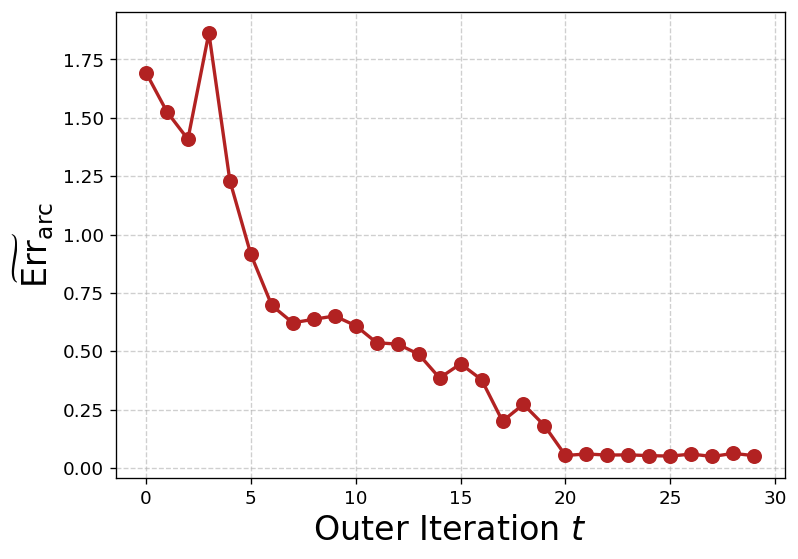

In [230]:
plot_error_convergence(out_cdf)

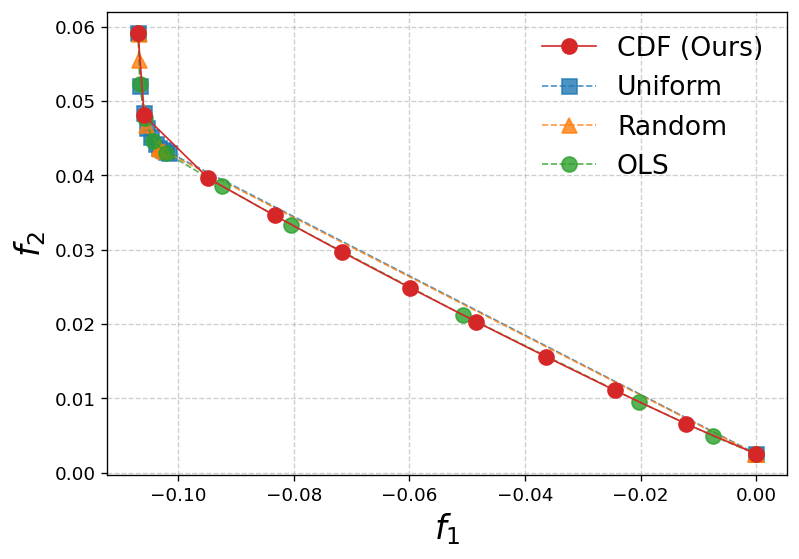

In [231]:
configs = [
    (out_uni, "s", "--", "Uniform"),
    (out_rand, "^", "--", "Random"),
    (out_ols, "o", "--", "OLS" )
]
plot_converged_fronts_regularized(out_cdf, configs)

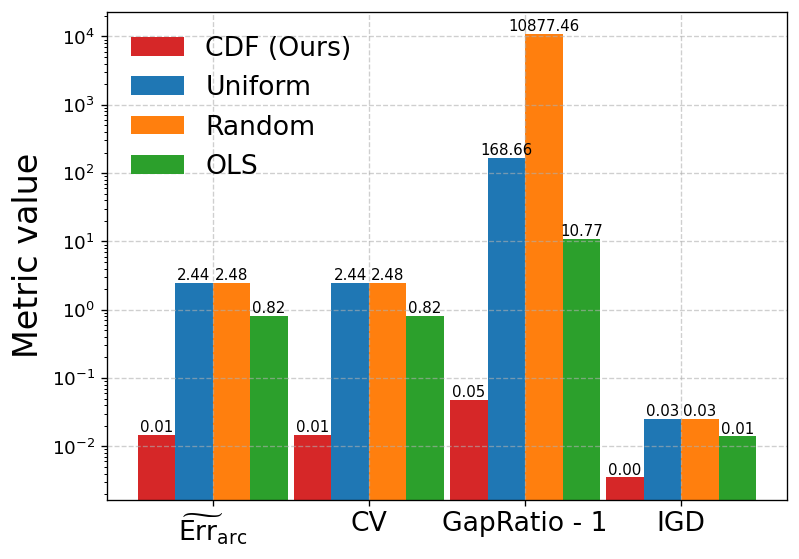

In [232]:
metrics = {
    "CDF (Ours)": {
        r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$": calculate_relative_rms_err(pf_cdf),
        "CV": arc_length_cv(pf_cdf),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_cdf) - 1),
        "IGD": igd(pf_cdf),
    },
    "Uniform": {
        r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$": calculate_relative_rms_err(pf_uni),
        "CV": arc_length_cv(pf_uni),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_uni) - 1),
        "IGD": igd(pf_uni),
    },
    "Random": {
        r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$": calculate_relative_rms_err(pf_rand),
        "CV": arc_length_cv(pf_rand),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_rand) - 1),
        "IGD": igd(pf_rand),
    },
    "OLS": {
        r"$\widetilde{\mathrm{Err}}_{\mathrm{arc}}$": calculate_relative_rms_err(pf_ols),
        "CV": arc_length_cv(pf_ols),
        "GapRatio - 1": abs(max_min_gap_ratio(pf_ols) - 1),
        "IGD": igd(pf_ols),
    },
}


plot_metric_bars(metrics)

In [233]:
def rollout_trajectories(model, pi, num_steps=80, num_envs=4):
    """Generates stochastic rollouts for a single policy."""
    state_to_idx = model["state_to_idx"]
    idx_to_state = model["idx_to_state"]
    treasure_mask = model["treasure_mask"]
    P = model["P"] # (S, A, S) deterministic
    
    start_s_idx = np.argmax(model["rho0"])
    
    all_paths = []
    
    for _ in range(num_envs):
        curr_s_idx = start_s_idx
        path = [idx_to_state[curr_s_idx]]
        
        for _ in range(num_steps):
            if treasure_mask[curr_s_idx] or idx_to_state[curr_s_idx] == ("terminal",):
                break
                
            prob_dist = pi[curr_s_idx]
            # Probabilities must sum to 1.0
            s_val = np.sum(prob_dist)
            if s_val > 1e-9:
                prob_dist = prob_dist / s_val
                a = np.random.choice(model["A"], p=prob_dist)
            else:
                a = np.random.choice(model["A"]) # fallback
            
            # Deterministic next state
            curr_s_idx = np.argmax(P[curr_s_idx, a])
            curr_state = idx_to_state[curr_s_idx]
            if curr_state != ("terminal",):
                path.append(curr_state)
        
        all_paths.append(path)
    return all_paths

In [234]:
def plot_policy_trajectories_separately(
    model,
    policy_sol_list,
    tau,
    method_name="CDF Refinement (Our Method)",
    n_rollouts=30,
    max_steps=80,
    panel_width=3.6,
    panel_height=4.8,
    arrow_freq=4,
):
    """
    Always plot in a 1 x N layout, no matter how large N is.

    For each policy, show:
      - rollout trajectory distribution
      - average time cost over simulations
      - average obtained treasure reward over simulations

    Returns
    -------
    stats : list of dict
        One dict per policy with:
            policy_idx, w, avg_time_cost, avg_treasure_reward, success_rate
    """
    grid = model["grid"]
    N = len(policy_sol_list)

    fig, axs = plt.subplots(
        1,
        N,
        figsize=(panel_width * N, panel_height),
        constrained_layout=True,
        squeeze=False,
    )
    axs = axs[0]

    map_colors = {
        "wall": "#2B2B2B",
        "water": "#F4FBFD",
        "treasure": "#8C6A0A",
        "text": "#FFD700",
        "gridline": "#D6EAF0",
        "traj": "#1f77b4",
    }

    def draw_background(ax):
        ax.set_facecolor(map_colors["water"])

        # grid lines
        for x in np.arange(-0.5, grid.shape[1], 1):
            ax.axvline(x, color=map_colors["gridline"], lw=0.7, zorder=0)
        for y in np.arange(-0.5, grid.shape[0], 1):
            ax.axhline(y, color=map_colors["gridline"], lw=0.7, zorder=0)

        # draw cells
        for r in range(grid.shape[0]):
            for c in range(grid.shape[1]):
                val = grid[r, c]
                if val == -10:  # wall
                    ax.add_patch(
                        plt.Rectangle(
                            (c - 0.5, r - 0.5), 1, 1,
                            color=map_colors["wall"], zorder=1
                        )
                    )
                elif val > 0:  # treasure
                    ax.add_patch(
                        plt.Rectangle(
                            (c - 0.5, r - 0.5), 1, 1,
                            color=map_colors["treasure"], alpha=0.9, zorder=1
                        )
                    )
                    ax.text(
                        c, r, f"{int(val)}",
                        color=map_colors["text"],
                        ha="center", va="center",
                        fontweight="bold", 
                        fontsize=12, 
                        zorder=50
                    )

        ax.axis("image")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(-0.5, grid.shape[1] - 0.5)
        ax.set_ylim(grid.shape[0] - 0.5, -0.5)

    def path_stats(path):
        """
        Given one rollout path = [(r0,c0), (r1,c1), ...],
        compute:
          - time cost = number of actions = len(path)-1
          - obtained treasure reward = treasure value at final state if final state is treasure, else 0
        """
        if len(path) == 0:
            return {
                "time_cost": np.nan,
                "treasure_reward": np.nan,
                "success": False,
            }

        final_r, final_c = path[-1]
        final_val = grid[int(final_r), int(final_c)]
        treasure_reward = float(final_val) if final_val > 0 else 0.0
        time_cost = max(len(path) - 1, 0)
        success = final_val > 0

        return {
            "time_cost": float(time_cost),
            "treasure_reward": treasure_reward,
            "success": bool(success),
        }

    summary_stats = []

    for i, sol in enumerate(policy_sol_list):
        ax = axs[i]
        draw_background(ax)

        pi = sol["pi"]
        w = sol.get("w", None)

        # rollout_trajectories is assumed to return a list of paths,
        # each path being a list of (row, col) states
        paths = rollout_trajectories(
            model,
            pi,
            num_steps=max_steps,
            num_envs=n_rollouts
        )

        time_costs = []
        treasure_rewards = []
        successes = []

        for path in paths:
            path_coords = np.array(path)
            if len(path_coords) < 2:
                st = path_stats(path)
                if not np.isnan(st["time_cost"]):
                    time_costs.append(st["time_cost"])
                    treasure_rewards.append(st["treasure_reward"])
                    successes.append(float(st["success"]))
                continue

            X = path_coords[:, 1]
            Y = path_coords[:, 0]

            # faint overlap shows route distribution for this policy
            ax.plot(
                X, Y,
                color=map_colors["traj"],
                linewidth=1.2,
                alpha=0.10,
                zorder=3,
                solid_capstyle="round",
            )

            U = np.diff(X)
            V = np.diff(Y)
            idx = np.arange(0, len(U), arrow_freq)

            if len(idx) > 0:
                ax.quiver(
                    X[:-1][idx], Y[:-1][idx],
                    U[idx], V[idx],
                    angles="xy",
                    scale_units="xy",
                    scale=1,
                    color=map_colors["traj"],
                    alpha=0.12,
                    width=0.0035,
                    headwidth=4.0,
                    headlength=5.0,
                    headaxislength=4.5,
                    zorder=4,
                )

            ax.scatter(
                X[-1], Y[-1],
                s=10,
                color=map_colors["traj"],
                alpha=0.18,
                edgecolors="none",
                zorder=5,
            )

            st = path_stats(path)
            time_costs.append(st["time_cost"])
            treasure_rewards.append(st["treasure_reward"])
            successes.append(float(st["success"]))

        avg_time_cost = float(np.mean(time_costs)) if len(time_costs) > 0 else np.nan
        avg_treasure_reward = float(np.mean(treasure_rewards)) if len(treasure_rewards) > 0 else np.nan
        success_rate = float(np.mean(successes)) if len(successes) > 0 else np.nan

        summary_stats.append({
            "policy_idx": i + 1,
            "w": w,
            "avg_time_cost": avg_time_cost,
            "avg_treasure_reward": avg_treasure_reward,
            "success_rate": success_rate,
        })

        # subplot title
        if w is None:
            title_str = f"Policy {i+1}"
        else:
            title_str =  f"$w={w:.3f}$" # f"Policy {i+1}\n$w={w:.3f}$"

        ax.set_title(title_str, 
                     # fontsize=20, 
                     fontweight="bold")

        # show summary under each subplot
        stat_text = (
            f"Avg. time: {avg_time_cost:.1f}\n"
            f"Avg. treasure: {avg_treasure_reward:.1f}"
            # f"success: {100*success_rate:.1f}%"
        )
        ax.text(
            0.5, -0.03,
            stat_text,
            transform=ax.transAxes,
            ha="center", va="top",
            # fontsize=20
        )

    fig.suptitle(
        f"{method_name}: trajectory distribution ($\\tau$={tau})",
        fontsize=22,
        fontweight="bold"
    )
    plt.savefig(FIG_PATH+method_name+".pdf", bbox_inches="tight")
    
    plt.show()

    # Also print a clean summary table
    print(f"\n{method_name} summary over {n_rollouts} rollouts per policy")
    print("-" * 78)
    for row in summary_stats:
        w_str = "N/A" if row["w"] is None else f"{row['w']:.4f}"
        print(
            f"Policy {row['policy_idx']:>2} | "
            f"w = {w_str:>7} | "
            f"avg time cost = {row['avg_time_cost']:>6.2f} | "
            f"avg treasure = {row['avg_treasure_reward']:>6.2f} | "
            f"success = {100*row['success_rate']:>6.2f}%"
        )

    return summary_stats

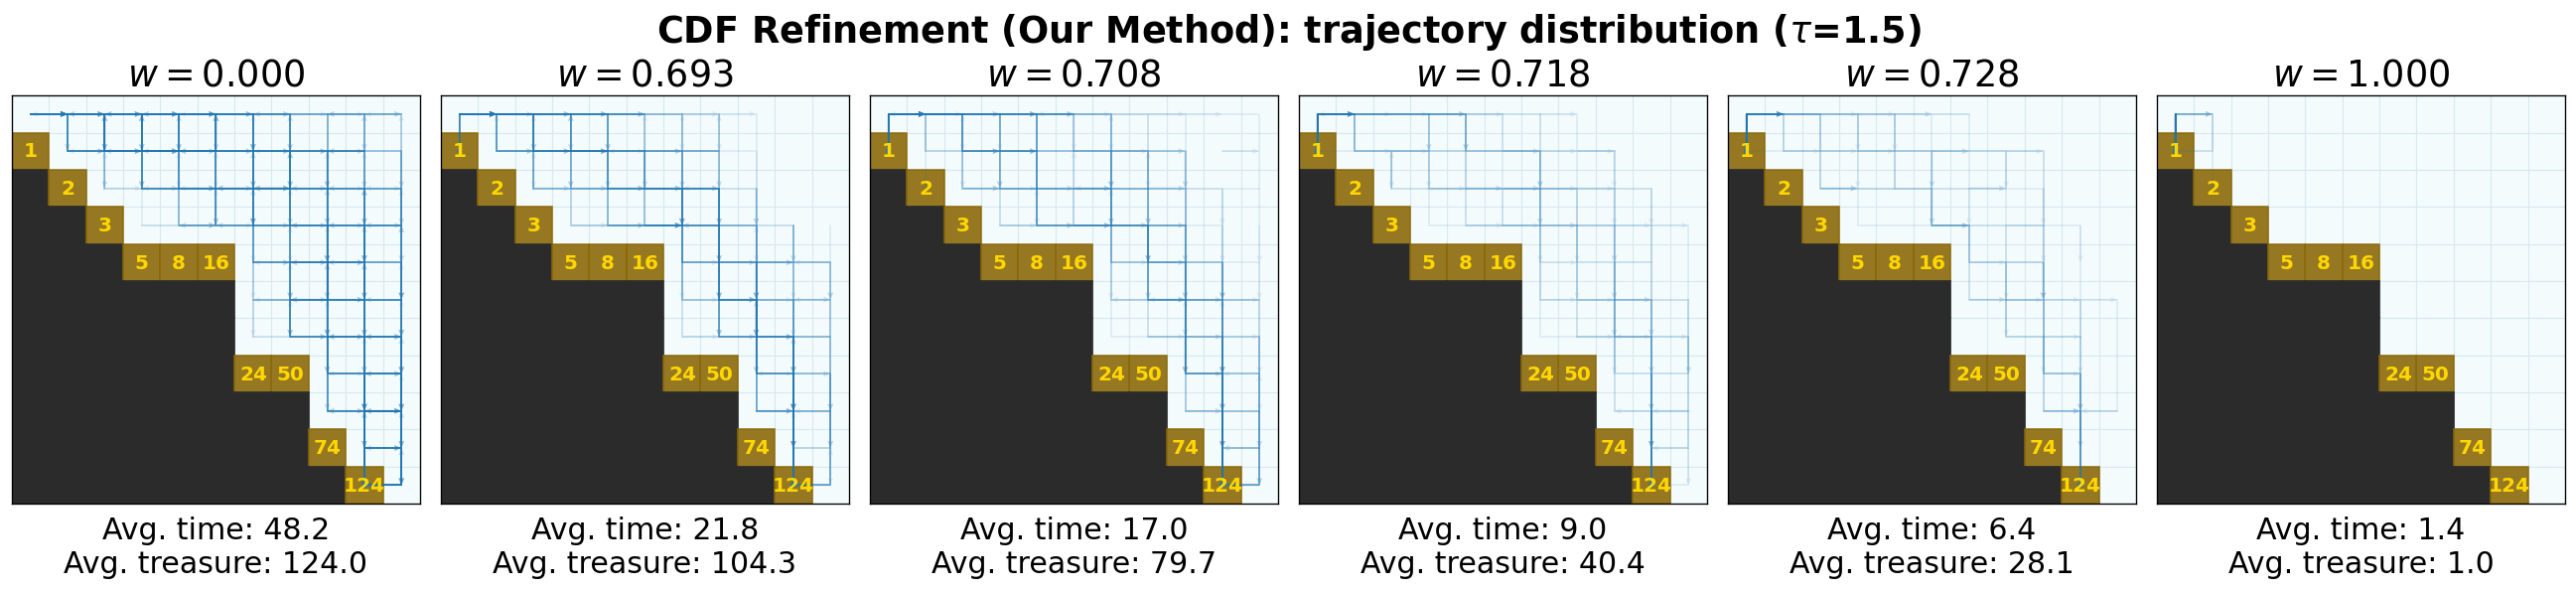


CDF Refinement (Our Method) summary over 50 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  48.18 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.6931 | avg time cost =  21.78 | avg treasure = 104.32 | success = 100.00%
Policy  3 | w =  0.7078 | avg time cost =  17.02 | avg treasure =  79.74 | success = 100.00%
Policy  4 | w =  0.7175 | avg time cost =   8.96 | avg treasure =  40.36 | success = 100.00%
Policy  5 | w =  0.7282 | avg time cost =   6.38 | avg treasure =  28.06 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.40 | avg treasure =   1.02 | success = 100.00%


In [85]:
results_cdf_last = out_cdf["policy_history"][-1]

stats_cdf = plot_policy_trajectories_separately(
    model,
    results_cdf_last,
    tau=tau,
    method_name="CDF Refinement (Our Method)",
    n_rollouts=50,
    max_steps=200,
)

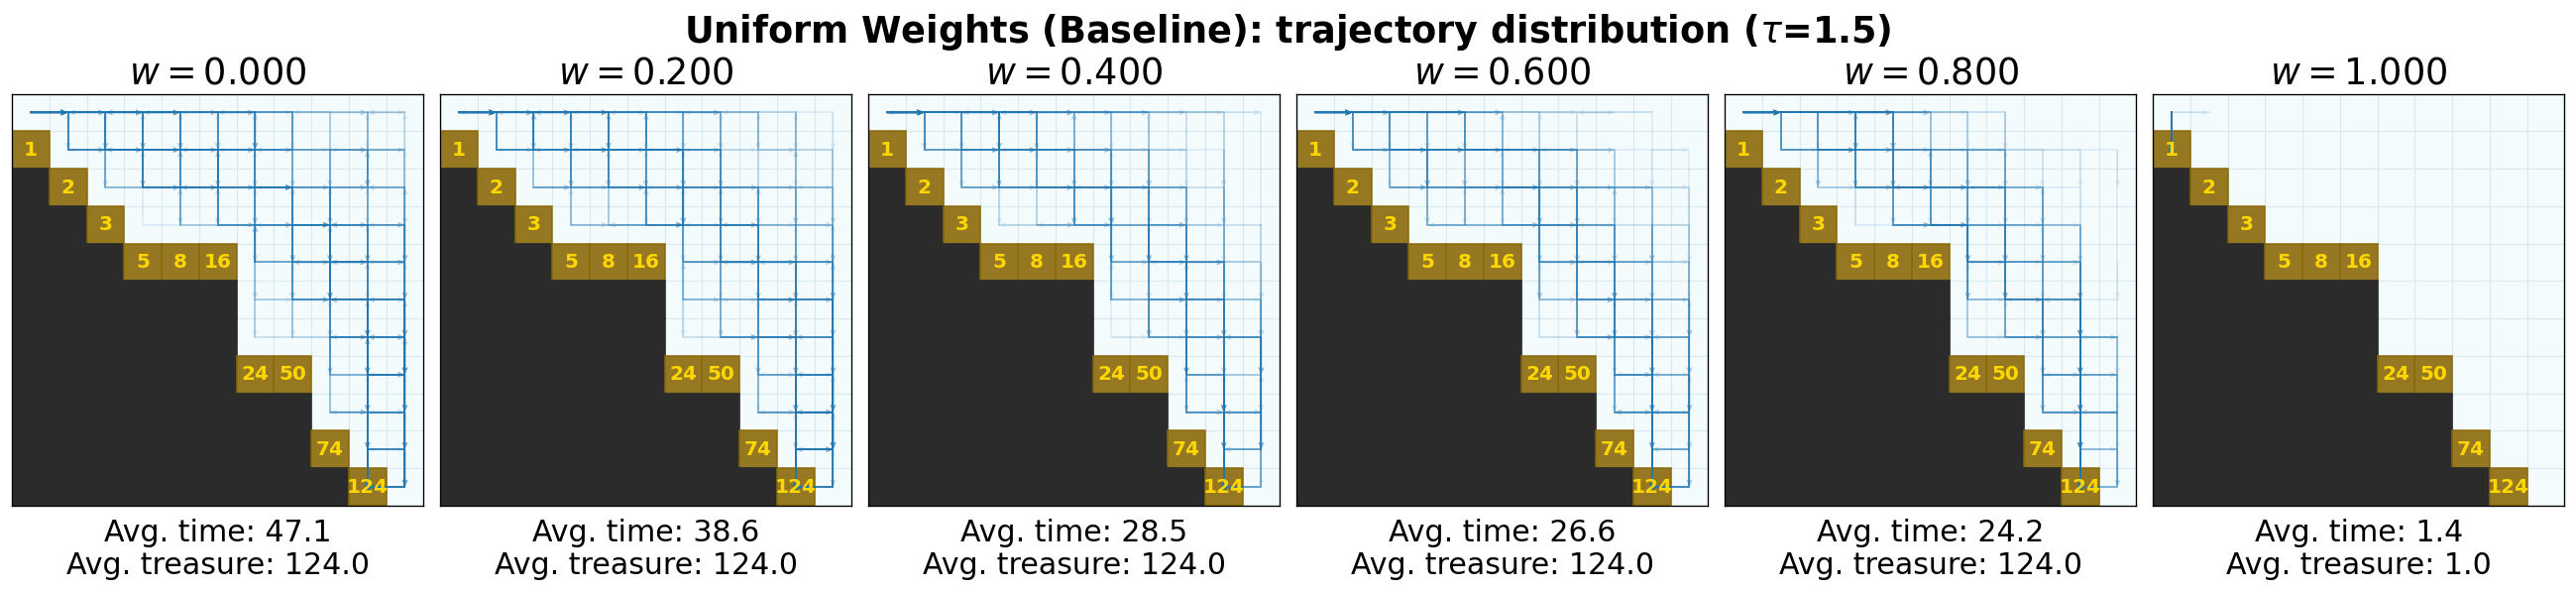


Uniform Weights (Baseline) summary over 50 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  47.10 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.2000 | avg time cost =  38.60 | avg treasure = 124.00 | success = 100.00%
Policy  3 | w =  0.4000 | avg time cost =  28.54 | avg treasure = 124.00 | success = 100.00%
Policy  4 | w =  0.6000 | avg time cost =  26.62 | avg treasure = 124.00 | success = 100.00%
Policy  5 | w =  0.8000 | avg time cost =  24.20 | avg treasure = 124.00 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.38 | avg treasure =   1.00 | success = 100.00%


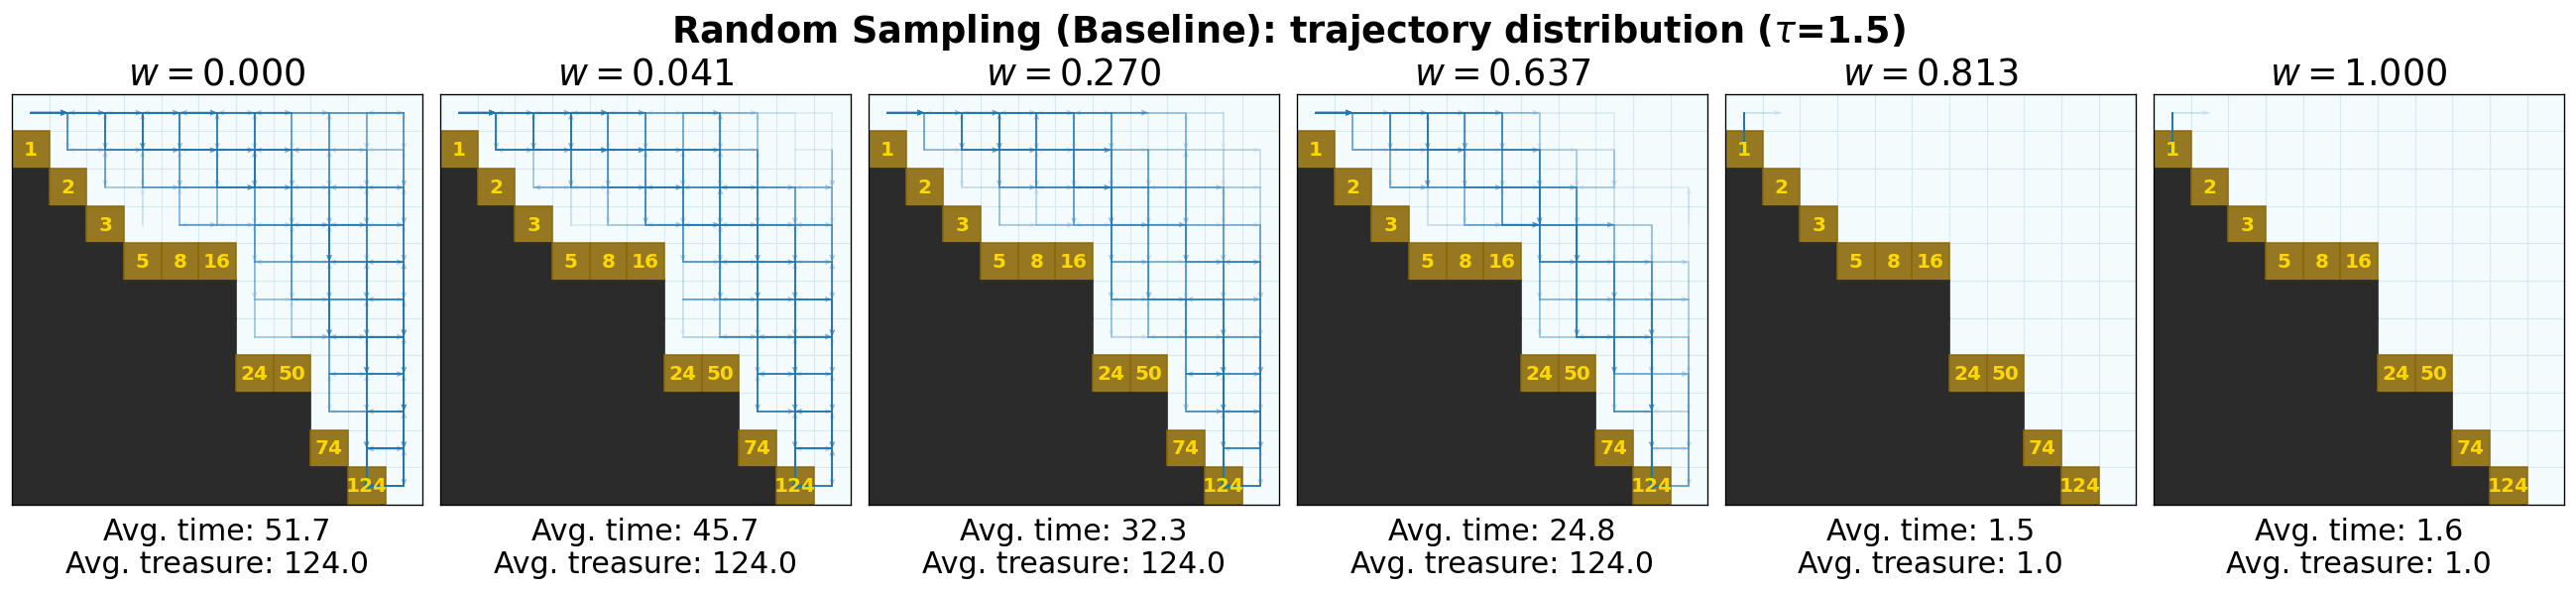


Random Sampling (Baseline) summary over 50 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  51.68 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.0410 | avg time cost =  45.70 | avg treasure = 124.00 | success = 100.00%
Policy  3 | w =  0.2698 | avg time cost =  32.34 | avg treasure = 124.00 | success = 100.00%
Policy  4 | w =  0.6370 | avg time cost =  24.78 | avg treasure = 124.00 | success = 100.00%
Policy  5 | w =  0.8133 | avg time cost =   1.54 | avg treasure =   1.00 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.56 | avg treasure =   1.00 | success = 100.00%


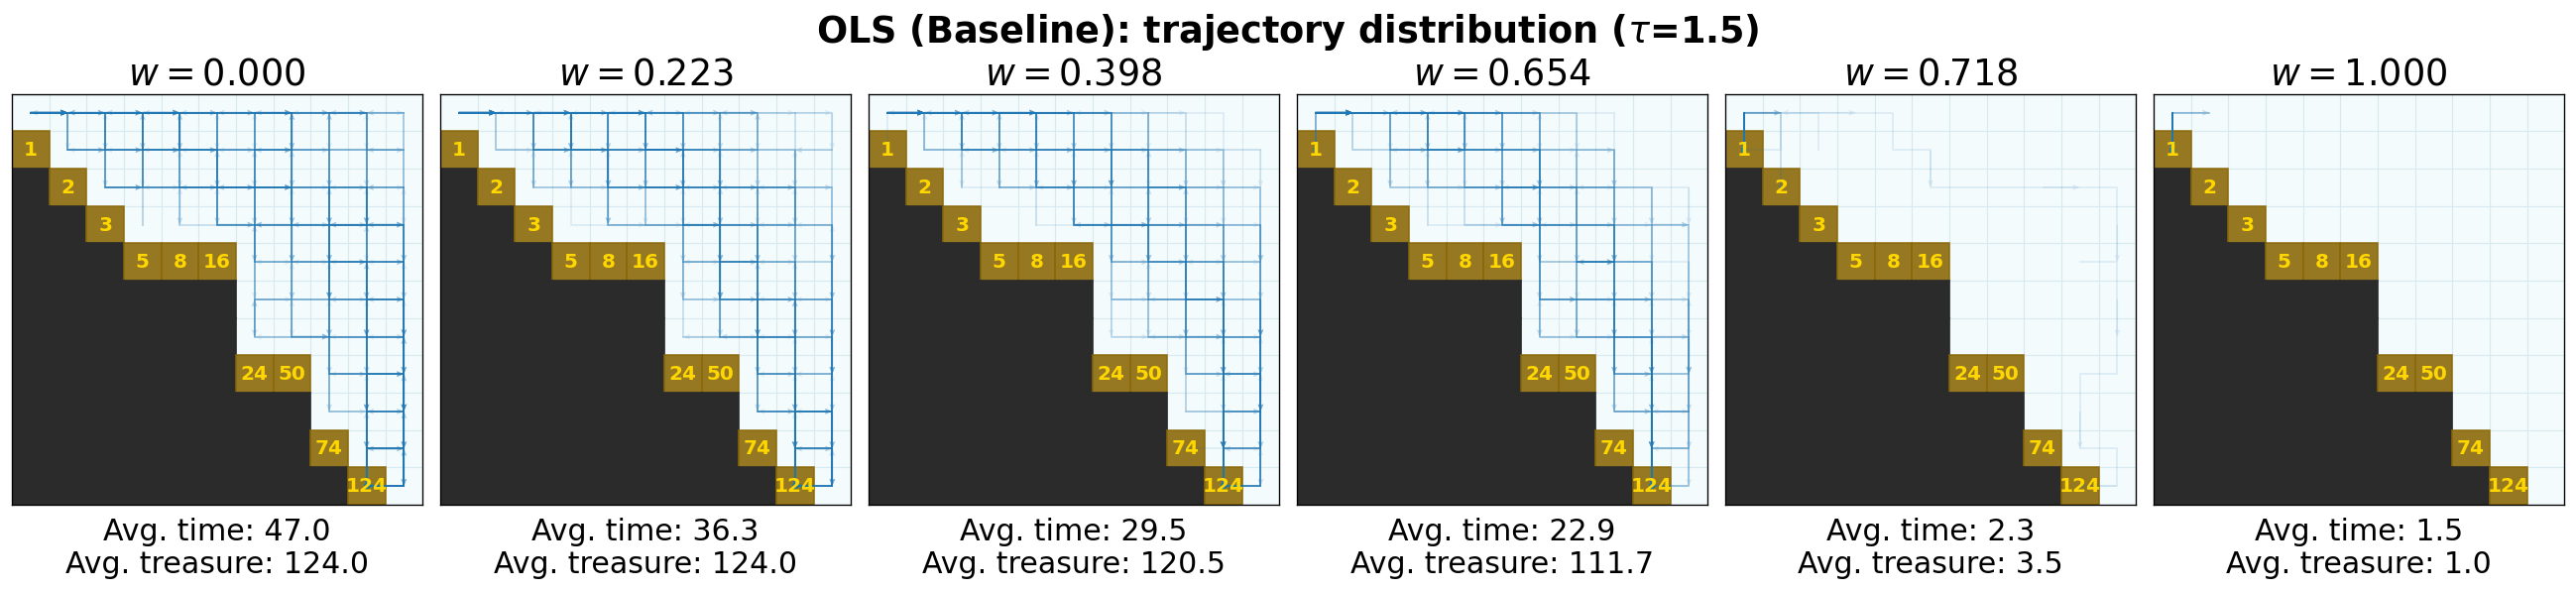


OLS (Baseline) summary over 50 rollouts per policy
------------------------------------------------------------------------------
Policy  1 | w =  0.0000 | avg time cost =  46.98 | avg treasure = 124.00 | success = 100.00%
Policy  2 | w =  0.2228 | avg time cost =  36.26 | avg treasure = 124.00 | success = 100.00%
Policy  3 | w =  0.3976 | avg time cost =  29.48 | avg treasure = 120.54 | success = 100.00%
Policy  4 | w =  0.6536 | avg time cost =  22.88 | avg treasure = 111.70 | success = 100.00%
Policy  5 | w =  0.7177 | avg time cost =   2.34 | avg treasure =   3.50 | success = 100.00%
Policy  6 | w =  1.0000 | avg time cost =   1.48 | avg treasure =   1.00 | success = 100.00%


In [86]:
def get_results_list(obj):
    if isinstance(obj, dict) and "results" in obj:
        return obj["results"]
    return obj

stats_uni = plot_policy_trajectories_separately(
    model,
    get_results_list(out_uni),
    tau=tau,
    method_name="Uniform Weights (Baseline)",
    n_rollouts=50,
    max_steps=200,
)

stats_rand = plot_policy_trajectories_separately(
    model,
    get_results_list(out_rand),
    tau=tau,
    method_name="Random Sampling (Baseline)",
    n_rollouts=50,
    max_steps=200,
)

stats_ols = plot_policy_trajectories_separately(
    model,
    get_results_list(out_ols),
    tau=tau,
    method_name="OLS (Baseline)",
    n_rollouts=50,
    max_steps=200,
)

### Verify the conditions that enables hidden convexity in occupancy measure space

In [22]:
# Active-state trimming: remove absorbing terminal state
def get_active_model_arrays(model):
    terminal_idx = model["terminal_idx"]
    keep = [i for i in range(model["S"]) if i != terminal_idx]

    P_active = model["P"][np.ix_(keep, range(model["A"]), keep)]
    R_active = model["R"][np.ix_(keep, range(model["A"]), range(model["R"].shape[2]))]
    rho0_active = model["rho0"][keep]

    return P_active, R_active, rho0_active, keep



# Policy -> discounted occupancy on active states x actions
def policy_to_discounted_occupancy_active(pi, P_sa_s, rho0, gamma):
    S, A = pi.shape

    P_pi = np.einsum("sa,san->sn", pi, P_sa_s)
    M = np.eye(S) - gamma * P_pi.T
    rhs = (1.0 - gamma) * rho0
    d = np.linalg.solve(M, rhs)

    mu = d[:, None] * pi
    mu = np.maximum(mu, 0.0)

    # numerical renormalization
    Z = mu.sum()
    if Z > 0:
        mu /= Z
        d = mu.sum(axis=1)

    return mu, d



# Build flow matrix on active states
def build_flow_matrix_active(P_sa_s, gamma):
    S, A, S2 = P_sa_s.shape
    assert S == S2

    Aeq = np.zeros((S, S * A))
    for s in range(S):
        for sp in range(S):
            for a in range(A):
                idx = sp * A + a
                if sp == s:
                    Aeq[s, idx] += 1.0
                Aeq[s, idx] -= gamma * P_sa_s[sp, a, s]
    return Aeq



# Projection onto ker(J)
def project_to_kernel(J, v, rcond=1e-12):
    if J.size == 0:
        return v.copy()

    JJt = J @ J.T
    rhs = J @ v
    coeff = np.linalg.lstsq(JJt, rhs, rcond=rcond)[0]
    return v - J.T @ coeff



# Dense-grid verification using policy solver
def verify_conditions_dense_w_grid(
    model,
    gamma,
    tau,
    pi_ref,
    solve_policy_scalarization,
    w_grid=None,
    visit_tol=1e-8,
    zero_tol=1e-10,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=None,
    verbose=True,
):
    """
    Verifies:
      1) dmin > 0 on visited active states
      2) E - gamma P full column rank  <=>  Aeq full row rank
      3) tangent-gap empirical lower bound on dense interior weights
    """
    if w_grid is None:
        w_grid = np.linspace(1e-12, 1 - 1e-12, 1001)

    # active states only = non-obstacle, non-terminal
    P_active, R_active, rho0_active, keep = get_active_model_arrays(model)
    S, A = P_active.shape[:2]

    R1_active = R_active[:, :, 0]
    R2_active = R_active[:, :, 1]

    # full-rank check
    Aeq = build_flow_matrix_active(P_active, gamma)
    rank_Aeq = np.linalg.matrix_rank(Aeq)
    full_row_rank = (rank_Aeq == S)

    # tangent-gap uses grad difference of linear parts
    grad_diff = (R2_active - R1_active).reshape(-1)

    results = []
    tangent_proj_norms = []
    dmins_active = []

    logits_init = None

    for i, w in enumerate(w_grid):
        sol = solve_policy_scalarization(
            w=w,
            P=P_active,
            R=R_active,
            rho0=rho0_active,
            gamma=gamma,
            tau=tau,
            pi_ref=pi_ref,
            logits_init=logits_init,
            lr=lr,
            maxiter=maxiter,
            tol=tol,
            device=device,
            verbose=False,
        )

        # warm start next solve
        if isinstance(sol, dict) and "logits" in sol:
            logits_init = sol["logits"]

        pi = sol["pi"]
        mu, d = policy_to_discounted_occupancy_active(pi, P_active, rho0_active, gamma)

        active_state_mask = d > visit_tol
        dmin_active = float(np.min(d[active_state_mask])) if np.any(active_state_mask) else np.nan
        dmins_active.append(dmin_active)

        x = mu.reshape(-1)
        zero_idx = np.where(x <= zero_tol)[0]

        if len(zero_idx) > 0:
            J_nonneg = np.eye(S * A)[zero_idx]
            J = np.vstack([Aeq, J_nonneg])
        else:
            J = Aeq.copy()

        proj_grad_diff = project_to_kernel(J, grad_diff)
        proj_norm = float(np.linalg.norm(proj_grad_diff, 2))
        tangent_proj_norms.append(proj_norm)

        results.append({
            "w": float(w),
            "pi": pi,
            "mu": mu,
            "d": d,
            "num_active_states": int(np.sum(active_state_mask)),
            "dmin_active": dmin_active,
            "num_zero_coords": int(len(zero_idx)),
            "proj_grad_diff_norm": proj_norm,
        })

        if verbose and (i % 100 == 0 or i == len(w_grid) - 1):
            print(
                f"[{i+1:4d}/{len(w_grid)}] "
                f"w={w:.6f}, "
                f"#active={np.sum(active_state_mask):2d}, "
                f"dmin_active={dmin_active:.3e}, "
                f"||Proj grad diff||={proj_norm:.3e}"
            )

    report = {
        "num_weights": len(w_grid),
        "w_min": float(np.min(w_grid)),
        "w_max": float(np.max(w_grid)),
        "Aeq_shape": Aeq.shape,
        "rank_Aeq": int(rank_Aeq),
        "full_row_rank_Aeq": full_row_rank,
        "condition_E_minus_gamma_P_full_column_rank": full_row_rank,
        "visit_tol": visit_tol,
        "dmin_active_over_dense_grid": float(np.nanmin(dmins_active)),
        "condition_dmin_active_only": bool(np.nanmin(dmins_active) > visit_tol),
        "tangent_gap_empirical_c_hat_dense_grid": float(np.min(tangent_proj_norms)),
        "tangent_gap_holds_empirically": bool(np.min(tangent_proj_norms) > 0.0),
        "argmin_dmin_w": float(results[int(np.nanargmin(dmins_active))]["w"]),
        "argmin_tangent_gap_w": float(results[int(np.argmin(tangent_proj_norms))]["w"]),
        "results": results,
    }

    print("\n=== Dense-grid verification report on active states only ===")
    print(f"weights checked: {report['num_weights']}")
    print(f"w range: [{report['w_min']:.3e}, {report['w_max']:.3e}]")
    print(f"Aeq shape: {report['Aeq_shape']}")
    print(f"rank(Aeq): {report['rank_Aeq']} / {Aeq.shape[0]}")
    print(f"Full-row-rank(Aeq): {report['full_row_rank_Aeq']}")
    print()
    print(f"visit_tol: {visit_tol:.1e}")
    print(f"min active-state d(s) over dense grid: {report['dmin_active_over_dense_grid']:.6e}")
    print(f"attained near w = {report['argmin_dmin_w']:.6f}")
    print(f"Condition dmin on visited active states only: {report['condition_dmin_active_only']}")
    print()
    print(f"Empirical tangent-gap lower bound c_hat: {report['tangent_gap_empirical_c_hat_dense_grid']:.6e}")
    print(f"attained near w = {report['argmin_tangent_gap_w']:.6f}")
    print(f"Tangent-gap holds empirically: {report['tangent_gap_holds_empirically']}")

    return report

In [23]:
def get_active_model_arrays(model):
    terminal_idx = model["terminal_idx"]
    keep = [i for i in range(model["S"]) if i != terminal_idx]

    P_active = model["P"][np.ix_(keep, range(model["A"]), keep)]
    R_active = model["R"][np.ix_(keep, range(model["A"]), range(model["R"].shape[2]))]
    rho0_active = model["rho0"][keep]

    return P_active, R_active, rho0_active, keep

P_active, R_active, rho0_active, keep = get_active_model_arrays(model)

pi_ref_active = np.full((P_active.shape[0], model["A"]), 1.0 / model["A"], dtype=float)

print("P_active shape:", P_active.shape)
print("R_active shape:", R_active.shape)
print("rho0_active shape:", rho0_active.shape)
print("pi_ref_active shape:", pi_ref_active.shape)

report_dense = verify_conditions_dense_w_grid(
    model=model,
    gamma=gamma,
    tau=tau,
    pi_ref=pi_ref_active,
    solve_policy_scalarization=solve_policy_scalarization,
    w_grid=np.linspace(0, 1, 1001),
    visit_tol=1e-8,
    zero_tol=1e-10,
    lr=0.01,
    maxiter=300,
    tol=1e-8,
    device=DEVICE,
    verbose=True,
)

P_active shape: (72, 4, 72)
R_active shape: (72, 4, 2)
rho0_active shape: (72,)
pi_ref_active shape: (72, 4)
[   1/1001] w=0.000000, #active=72, dmin_active=2.658e-06, ||Proj grad diff||=7.976e+01
[ 101/1001] w=0.100000, #active=63, dmin_active=1.748e-03, ||Proj grad diff||=7.480e+01
[ 201/1001] w=0.200000, #active=63, dmin_active=1.375e-03, ||Proj grad diff||=5.371e+01
[ 301/1001] w=0.300000, #active=63, dmin_active=7.847e-04, ||Proj grad diff||=4.033e+01
[ 401/1001] w=0.400000, #active=63, dmin_active=4.872e-04, ||Proj grad diff||=4.033e+01
[ 501/1001] w=0.500000, #active=63, dmin_active=3.128e-04, ||Proj grad diff||=4.033e+01
[ 601/1001] w=0.600000, #active=63, dmin_active=2.088e-04, ||Proj grad diff||=4.033e+01
[ 701/1001] w=0.700000, #active=63, dmin_active=1.438e-04, ||Proj grad diff||=5.371e+01
[ 801/1001] w=0.800000, #active=63, dmin_active=1.008e-04, ||Proj grad diff||=5.371e+01
[ 901/1001] w=0.900000, #active=63, dmin_active=7.161e-05, ||Proj grad diff||=5.371e+01
[1001/1001]